If the reason the decoding accuracy is higher than chance is related to behavioural distribution sampling issues. Then we would expect to see that the difference in behavioural sampling would correlated with decoding accuracy. Thus here we use the KS test to measure the maximum difference of the cumlative frequnecy distribution between the behavioural distriubtions of each class for x, y, speed and hdir. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [3]:
def extract_ks_and_accuracy_v2(data):
    """Extract average, max KS stats, and accuracies from the new dictionary structure.

    Args:
        data (dict): The nested dictionary containing KS statistics and accuracy data.

    Returns:
        tuple: Arrays for average KS values, max KS values, and accuracies.
    """
    avg_ks_values = []
    max_ks_values = []
    accuracies = []

    for session, trials in data["ks_data"].items():
        for trial, metrics in trials.items():
            if all(k in metrics for k in ['x', 'y', 'speed', 'hdir', 'accuracy']):
                ks_values = [metrics['x'], metrics['y'], metrics['speed'], metrics['hdir']]
                avg_ks_values.append(np.mean(ks_values))
                max_ks_values.append(np.max(ks_values))
                accuracies.append(metrics['accuracy'])

    return np.array(avg_ks_values), np.array(max_ks_values), np.array(accuracies)

def analyze_correlation(ks_values, accuracies):
    """Perform correlation analysis between KS statistics and accuracies.

    Args:
        ks_values (array-like): KS statistics values.
        accuracies (array-like): Decoding accuracy values.

    Returns:
        float: The correlation coefficient.
    """
    correlation = np.corrcoef(ks_values, accuracies)[0, 1]
    return correlation

In [4]:
with open(r"Z:\Jasmine_Laurence\single_trial_overview\decoding_spatial_efficiency\500ms_before_accuracy\500ms_before_accuracy_accuracy_ks_coeffs_data.pkl", "rb") as f:
    accuracy_ks_coeffs_data = pickle.load(f)

Correlation between average KS statistic and decoding accuracy: -0.043603421266128664
Correlation between max KS statistic and decoding accuracy: 0.020108691943072247


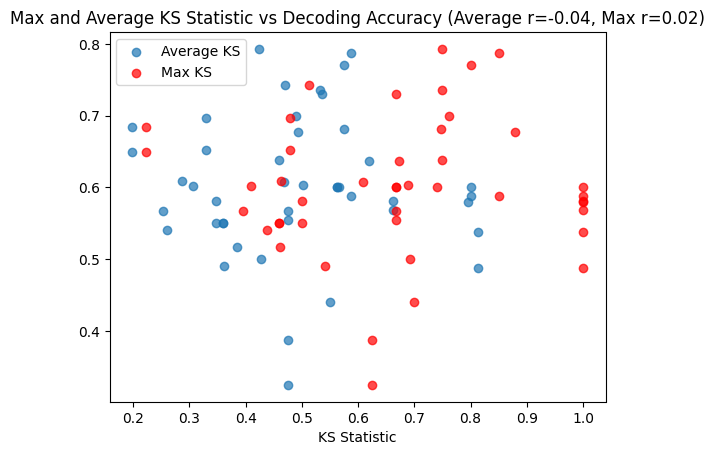

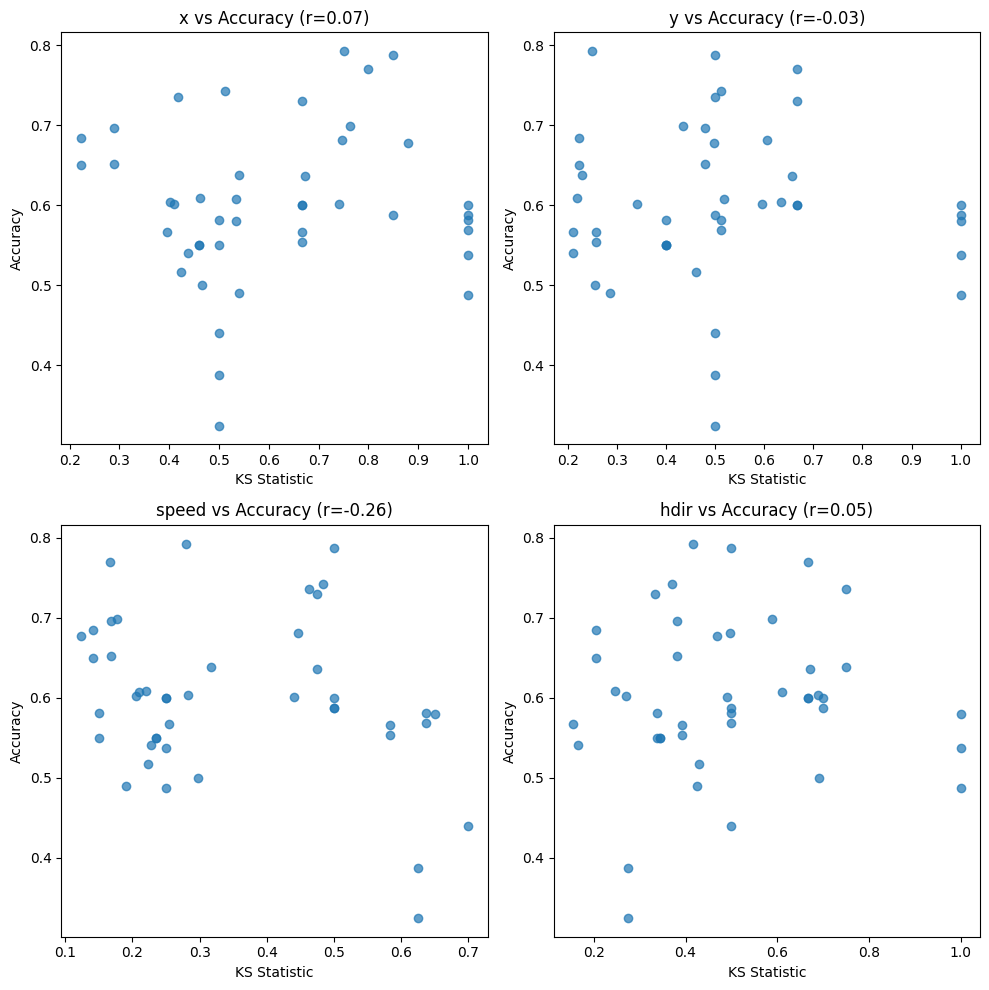

In [5]:
# Use the provided dictionary
avg_ks_values, max_ks_values, accuracies = extract_ks_and_accuracy_v2(accuracy_ks_coeffs_data)

if len(avg_ks_values) > 0 and len(max_ks_values) > 0 and len(accuracies) > 0:
    avg_correlation = analyze_correlation(avg_ks_values, accuracies)
    max_correlation = analyze_correlation(max_ks_values, accuracies)

    print(f"Correlation between average KS statistic and decoding accuracy: {avg_correlation}")
    print(f"Correlation between max KS statistic and decoding accuracy: {max_correlation}")

    plt.figure()
    plt.scatter(avg_ks_values, accuracies, alpha=0.7, label='Average KS')
    plt.scatter(max_ks_values, accuracies, alpha=0.7, label='Max KS', color='r')
    plt.xlabel('KS Statistic')
    plt.title(f"Max and Average KS Statistic vs Decoding Accuracy (Average r={avg_correlation:.2f}, Max r={max_correlation:.2f})")
    plt.legend()
    plt.show()

    ks_variables = ['x', 'y', 'speed', 'hdir']
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    axs = axs.ravel()

    for i, var in enumerate(ks_variables):
        ks_values = []
        accuracies = []
        for session, trials in accuracy_ks_coeffs_data["ks_data"].items():
            for trial, metrics in trials.items():
                if var in metrics and 'accuracy' in metrics:
                    ks_values.append(metrics[var])
                    accuracies.append(metrics['accuracy'])

        correlation = analyze_correlation(ks_values, accuracies)
        axs[i].scatter(ks_values, accuracies, alpha=0.7)
        axs[i].set_title(f'{var} vs Accuracy (r={correlation:.2f})')
        axs[i].set_xlabel("KS Statistic")
        axs[i].set_ylabel('Accuracy')

    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data for analysis.")